# 02 · Hyperventilation challenge

Canonical adult response: a late **theta build-up** (only ~a third of adults show it) that clears
within ~2 min of stopping.  We show %-band-power change vs the pre-HV eyes-open rest (top) and the
slow/fast ratio (bottom, delayed-recovery read-out).

In [1]:
import warnings, pathlib, sys
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

# Make the committed `analysis` package importable whether this notebook is
# launched from the repo root or from the notebooks/ folder.
_c = pathlib.Path.cwd()
REPO = next(p for p in [_c] + list(_c.parents) if (p / "analysis").is_dir())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
from analysis import dataset, eegkit as K

# Point DATA_DIR at any folder of EDFs named <subject><E|C><id>[_pN].edf
#   None -> repo data/  |  a path -> that folder  |  or set env EEG_DATA_DIR
DATA_DIR = None
recs = dataset.discover(DATA_DIR)

# Neutral per-recording labels (exp1, exp2, ctrl1, ctrl2) so participant codes
# never leak into figure titles / filenames.
_gi, LABEL = {}, {}
for _r in recs:
    _g = _r["group"]; _gi[_g] = _gi.get(_g, 0) + 1
    LABEL[_r["key"]] = ("exp" if _g == "E" else "ctrl") + str(_gi[_g])
def lbl(r): return LABEL[r["key"]]

FIG = REPO / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
IAF_DEF = 9.7

def ec_window(r):
    st = K.get_stages(K.load(r["path"]), r["key"])
    return [s for s in st if s[0].startswith("rest_close")][0]

def get_iaf(r):
    raw = K.load(r["path"]); ec = ec_window(r)
    _, live = K.get(raw, ec[1], ec[2])
    return K.iaf(raw, live, ec[1], ec[2])

def stage_of(r, nm):
    st = K.get_stages(K.load(r["path"]), r["key"])
    return [s for s in st if s[0] == nm]

print(f"discovered {len(recs)} recordings ->", {lbl(r): r["group"] for r in recs})
print("figures ->", str(FIG))


discovered 4 recordings -> {'exp1': 'E', 'exp2': 'E', 'ctrl1': 'C', 'ctrl2': 'C'}
figures -> /home/eugen/coding/ms-thesis/eeg-analysis/reports/figures


In [2]:
def hv_arrays(r):
    raw = K.load(r["path"]); fs = raw.info["sfreq"]
    st = K.get_stages(raw, r["key"])
    hv = [s for s in st if s[0] == "hypervent"]
    if not hv: return None
    hv = hv[0]; hv0, hv1 = hv[1], hv[2]
    IAF = get_iaf(r)
    ro1 = [s for s in st if s[0] == "rest_open1"][0]
    w0, w1 = ro1[1], min(raw.n_times / fs, hv1 + 300)
    W = 20
    tb, dp, th, al, be = [], [], [], [], []
    for t in np.arange(w0, w1 - W, 10):
        xi, live_w = K.get(raw, t, t + W)
        keep = [i for i, c in enumerate(live_w) if not c.startswith("Fp")]
        xk = xi[keep]
        tb.append(t + W / 2)
        dp.append(K.band_pow(xk, fs, 1, 4).mean()); th.append(K.band_pow(xk, fs, 4, 8).mean())
        al.append(K.band_pow(xk, fs, IAF - 2, IAF + 2).mean()); be.append(K.band_pow(xk, fs, 13, 30).mean())
    tb = np.array(tb)
    P = {k: np.array(v) for k, v in zip(("delta", "theta", "alpha", "beta"), (dp, th, al, be))}
    base_mask = (tb > ro1[1] + 20) & (tb < ro1[2] - 20)
    base = {k: P[k][base_mask].mean() for k in P}
    slowfast = (P["delta"] + P["theta"]) / (P["alpha"] + P["beta"]); sf_base = slowfast[base_mask].mean()
    def win(a, b): return (tb >= a) & (tb <= b)
    hv_m = win(hv0 + 10, hv1 - 10); hv_late = win(hv1 - 60, hv1)
    pc = lambda k, m: 100 * (P[k][m].mean() / base[k] - 1) if m.any() else np.nan
    ro2 = [s for s in st if s[0] == "rest_open2"]
    a_post = pc("alpha", win(*ro2[0][1:])) if ro2 else np.nan
    row = dict(recording=lbl(r), group=r["group"], theta_hv=pc("theta", hv_m),
               theta_late=pc("theta", hv_late), theta_p180=pc("theta", win(hv1 + 160, hv1 + 200)),
               alpha_postHV=a_post)
    return row, (tb, P, base, slowfast, sf_base, hv0, hv1, w0, w1, IAF)
rows, store = [], {}
for r in recs:
    out = hv_arrays(r)
    if out: rows.append(out[0]); store[r["key"]] = out[1]
print(pd.DataFrame(rows).round(0).to_string(index=False))
print("\nPositive theta build-up + slow decay = canonical; ~flat = absent; slow-clearing (>2 min) is the clinical flag.")


recording group  theta_hv  theta_late  theta_p180  alpha_postHV
     exp1     E      69.0        98.0        52.0         118.0
     exp2     E       2.0         6.0        19.0          36.0
    ctrl1     C      30.0        34.0        30.0          65.0

Positive theta build-up + slow decay = canonical; ~flat = absent; slow-clearing (>2 min) is the clinical flag.


## Two-panel response (experimental subject, session 1)

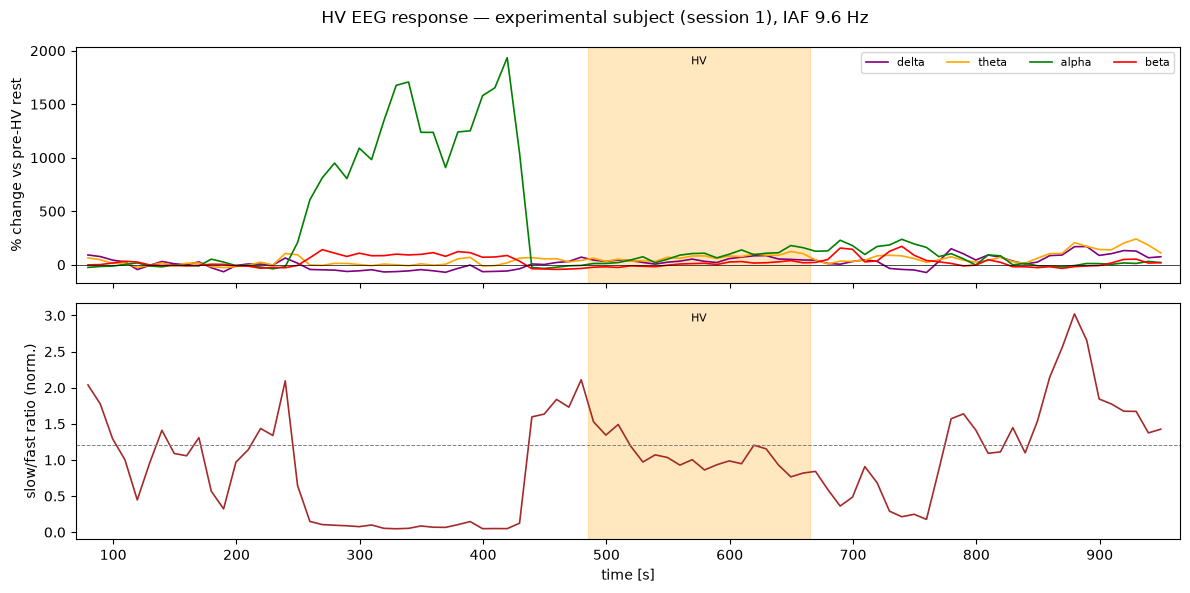

In [3]:
r = recs[0]; tb, P, base, slowfast, sf_base, hv0, hv1, w0, w1, IAF = store[r["key"]]
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for k, col in zip(("delta", "theta", "alpha", "beta"), ("purple", "orange", "green", "red")):
    axes[0].plot(tb, 100 * (P[k] / base[k] - 1), lw=1.2, color=col, label=k)
axes[0].axhline(0, color="k", lw=0.5)
axes[0].set_ylabel("% change vs pre-HV rest")
axes[0].legend(fontsize=8, ncol=4)
axes[1].plot(tb, slowfast / sf_base, lw=1.2, color="brown")
axes[1].axhline(1.2, color="grey", ls="--", lw=0.7)
axes[1].set_ylabel("slow/fast ratio (norm.)"); axes[1].set_xlabel("time [s]")
for ax in axes:
    ax.axvspan(hv0, hv1, color="orange", alpha=0.25)
    ax.text((hv0 + hv1) / 2, ax.get_ylim()[1] * 0.92, "HV", ha="center", fontsize=8)
    ax.set_xlim(w0, w1)
fig.suptitle(f"HV EEG response — experimental subject (session 1), IAF {IAF:.1f} Hz")
fig.tight_layout(); fig.savefig(FIG / "hv_exp.png", dpi=100); plt.show(); plt.close(fig)
